In [1]:
# import key libraries and kernel settings
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols, mixedlm
import time
from datetime import date
import matplotlib.lines as mlines

# updated src file changes are loaded
%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath(".."))

# Load data

In [3]:
from src.loading import load_data
# ------------------- Spatial Generalization 3.0 m/s
df = load_data("../data/spatial_generalization/spatial_generalization_3m.parquet")

df_full = df.copy()

In [5]:
print(len(np.unique(df_full['ppid'])))
np.unique(df_full['ppid'])

36


array(['p036', 'p037', 'p038', 'p039', 'p040', 'p041', 'p042', 'p043',
       'p044', 'p045', 'p046', 'p047', 'p048', 'p049', 'p052', 'p053',
       'p054', 'p056', 'p058', 'p060', 'p062', 'p063', 'p064', 'p066',
       'p067', 'p068', 'p069', 'p071', 'p072', 'p073', 'p074', 'p076',
       'p077', 'p078', 'p079', 'p080'], dtype=object)

water_speed_binary is acting strange: Implementing fix...
res: float64
0        R30
1        R60
2        L30
3        L60
4        R60
        ... 
14000    L30
14001    L30
14002    L60
14003    R30
14004    R60
Name: target_x_label, Length: 14000, dtype: category
Categories (4, object): ['L60' < 'L30' < 'R30' < 'R60']
0        R30
1        R60
2        L30
3        L60
4        R60
        ... 
14000    L30
14001    L30
14002    L60
14003    R30
14004    R60
Name: target_x_label, Length: 14000, dtype: category
Categories (4, object): ['L60' < 'L30' < 'R30' < 'R60']
target_hit
False   -148.5813
True      -5.2586
Name: signed_euclidean_cm, dtype: float64
target_hit
False    148.5813
True       5.2313
Name: signed_euclidean_cm, dtype: float64


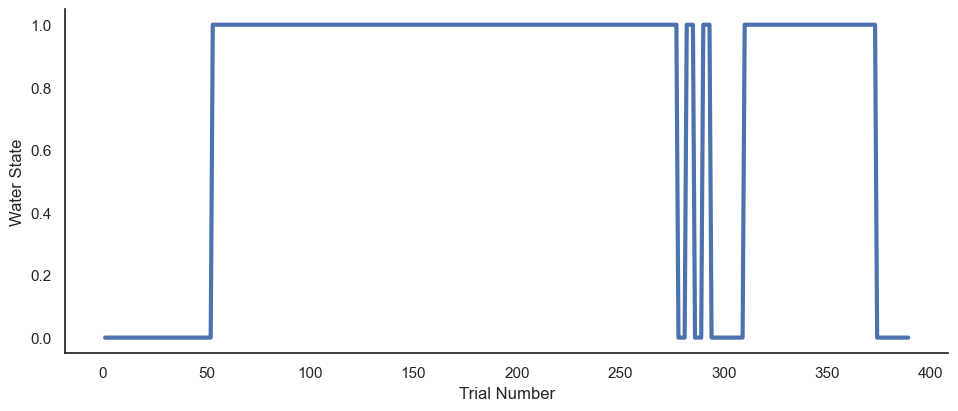

In [7]:

# fix water_speed_binary if needed
from pandas.api.types import is_integer_dtype

if not is_integer_dtype(df_full['water_speed_binary']):

    print('water_speed_binary is acting strange: Implementing fix...')
    
    df_full['water_speed_binary2'] = (df_full['water_speed_m_s'] != 0.0).astype(int).copy()
    df_full['water_speed_binary'] = df_full['water_speed_binary2'].copy()
    
    # drops redundant col
    df_full.drop(columns=['water_speed_binary2'], inplace=True)
    


# add new variables

df_full['lateral_error_x'] = (df_full['min_pos_from_target_x'] - df_full['target_position_x']) # 
df_full['depth_error_z'] = (df_full['min_pos_from_target_z'] - df_full['target_position_z']) 

# convert key columns to cm:
from src.convert_to_cm import convert_to_cm

df_labeled = convert_to_cm(df_full,
              cols=[
                    'min_pos_from_target_x',
                    'min_pos_from_target_z',
                    'target_position_x',
                    'target_position_z',
                    'lateral_error_x',
                    'depth_error_z'
                   ])

print('res:', df_labeled['target_position_x'].dtypes)

# label ppid by water speed
from src.label_water_speed_ppid import label_water_condtion_ppid
df_labeled = label_water_condtion_ppid(df_labeled, ppid_col='ppid', water_col='water_speed_m_s', selected_speeds=[-3.0,-2.0,0.0]).copy() 

# order targets

# adjust target label
target_mapping = {
    "p0.6": "R60",
    "p0.3": "R30",
    "neg0.3": "L30",
    "neg0.6": "L60"
}
df_labeled['target_x_label'] = df_labeled['target_x_label'].map(target_mapping).copy()

from src.features import order_targets
df_labeled['target_position_x'] = order_targets(df_labeled.copy())
df_labeled['target_x_label'] = order_targets(df_labeled.copy())


# signed euclidian distance
df_labeled['signed_euclidean_cm'] = (df_labeled['distance_from_target'] * 100) * np.sign(df_labeled['lateral_error_x_cm'])
print(df_labeled.groupby(['target_hit'])['signed_euclidean_cm'].min())
print(df_labeled.groupby(['target_hit'])['signed_euclidean_cm'].max())


# Generate a less ambiguous label for set_order reflecting the first target pair positions (left, first digit; right, second digit); underscore seperates the second pair
df_labeled['set_order'] = df_labeled['set_order'].cat.rename_categories({
    '1': '63_36',
    '2': '36_63'
}).copy()

# ensures PCA compatibility
df_labeled['water_speed_m_s'] = df_labeled['water_speed_m_s'].replace(0.0, 0.0001).copy()


# # remove trials that do not cross a certain threshold in the z-plane (i.e, trials that did not exceed 70 cm in the z-plane)
# from src.cleaning import crossed_threshold

# # make column checking if ball crossed 70.0 cm on z axis
# df_labeled['crossed_threshold'] = df_labeled.apply(
#     lambda row: crossed_threshold(row, col="ball_pos_z", val=0.70), # 70 cm
#         axis=1
# ).copy()
# # check
# print(df_labeled['crossed_threshold'].value_counts())
# # print(df_labeled['ball_pos_z'].describe())

# # Make a seperate df without trials that did not cross threshold
# df_filt = df_labeled[df_labeled['crossed_threshold']].copy() # retains rows where crossed_threshold == True

# # reduce df to key cols
# from src.cleaning import extract_key_columns
# df_small_filt = extract_key_columns(df_filt, cols=['experiment', 'ppid_full', 'speed_label', 'target_x_label', 'target_position_x_cm', 
#                                                    'target_position_z_cm', 'trial_num',
#                                                    'trial_num_target', 
#                                                    'launch_angle', 'launch_deviation', 'launch_Speed','distance_from_target', 'ball_dist_to_center_cm', 
#                                                    'signed_euclidean_cm', 'lateral_error_x_cm', 'depth_error_z_cm', 'target_hit', 'water_speed_binary', 
#                                                    'water_speed_m_s', 'sign_label','set_order', 'min_pos_from_target_x_cm', 'min_pos_from_target_z_cm',
#                                                    'target_angle_90', 'ball_pos_x', 'ball_pos_z','final_ball_pos_x']).copy()


# # check participant counts per group:
# from src.features import get_sample_sizes
# get_sample_sizes(df_small_filt, group_cols=['speed_label','experiment', 'set_order'], ppid_col='ppid_full')

from src.plotting import plot_trial_schedule
# trial schedule plot
g = plot_trial_schedule(df_labeled, context='poster', font_scale=3, y_col='water_speed_binary')


In [8]:
df_labeled.columns

Index(['experiment', 'ppid', 'session_num', 'trial_num', 'block_num',
       'trial_num_in_block', 'start_time', 'end_time', 'hand', 'target_hit',
       'final_ball_state', 'type', 'target_position_x', 'target_position_y',
       'target_position_z', 'target_width', 'launch_direction',
       'before_launch_velocity_x', 'before_launch_velocity_z',
       'before_launch_speed', 'before_launch_angle', 'current_force',
       'water_inertia', 'water_speed_m_s', 'launch_angle', 'launch_Speed',
       'slow_counter', 'ball_pos_x', 'ball_pos_z', 'ball_time',
       'ball_dist_from_target', 'closest_center_ball_pos_x',
       'closest_center_ball_pos_z', 'final_ball_pos_x', 'final_ball_pos_z',
       'turning_absolute_x', 'turning_absolute_y', 'distance_from_target',
       'min_pos_from_target_x', 'min_pos_from_target_z', 'total_score',
       'step_0_time', 'step_1_time', 'step_2_time', 'ball_dist_to_center_cm',
       'water_speed_binary', 'target_angle_90', 'launch_deviation',
       'la

In [ ]:
### SPEED 3.0 Trial Schedule

In [9]:
from src.add_phases import label_phases, df_add_phases

assert (df_labeled['experiment'].str.startswith('novel')).all(),  "Ensure you selected the correct data."

phases = label_phases(n_phases=7,
                      phase_names = ['familiarization',
                                   'baseline',
                                   'training_1',
                                   'washout_ST',
                                   'washout_1_AT',
                                   'training_2',
                                   'washout_2_AT'])

df_phases = df_add_phases(df_labeled, 
                           phase_array=phases,
                          trial_lo = np.array([1,21,53,278,294,310,374]),
                        trial_hi = np.array([20,52,277,293,309,373,389])
)

from src.add_cycles import add_cycles
df_phases = add_cycles(df_phases,
                       n_trials=4,
                       ppid_col='ppid_full',
                       target_col='target_x_label'
                       ).copy()


In [46]:
print(df_phases.groupby(['phase'])['trial_num'].agg(['min','max']))

                 min  max
phase                    
baseline          21   52
familiarization    1   20
training_1        53  277
training_2       310  373
washout_1_AT     294  309
washout_2_AT     374  389
washout_ST       278  293


In [11]:
# filter out familiarization (i.e, starts with an 'f')
df_nf = df_phases[~df_phases['phase'].str.startswith('f')].copy()

# remove trials that do not cross a certain threshold in the z-plane (i.e, trials that did not exceed 70 cm in the z-plane)
from src.cleaning import crossed_threshold

# make column checking if ball crossed 70.0 cm on z axis
df_nf['crossed_threshold'] = df_nf.apply(
    lambda row: crossed_threshold(row, col="ball_pos_z", val=0.70), # 70 cm
        axis=1
).copy()
# check
print(df_nf['crossed_threshold'].value_counts())

# Make a seperate df without trials that did not cross threshold
df_filt = df_nf[df_nf['crossed_threshold']].copy() # retains rows where crossed_threshold == True

# reduce df to key cols
from src.cleaning import extract_key_columns
df_small_filt = extract_key_columns(df_filt).copy()


# check participant counts per group:
from src.features import get_sample_sizes
get_sample_sizes(df_small_filt, group_cols=['speed_label','experiment'], ppid_col='ppid_full')

crossed_threshold
True     12972
False      309
Name: count, dtype: int64


C:\Users\jacob\water_current_MA\src\features.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(group_cols).size()


speed_label  experiment                          
-3.0         novel_TD_3.0M_spatial_generalization    16
             novel_TU_3.0M_spatial_generalization    20
dtype: int64

In [ ]:
print(df_small_filt.columns)
df_small_filt.head()

target: L30


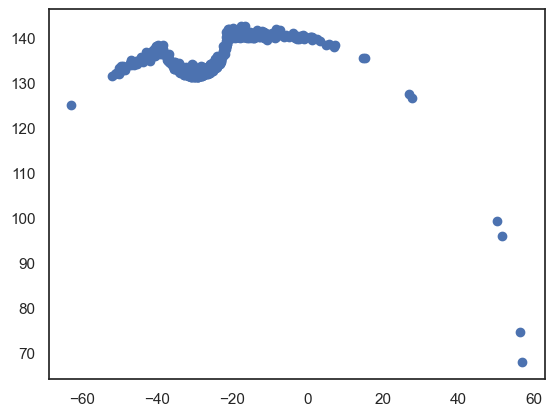

0.637
target: L60


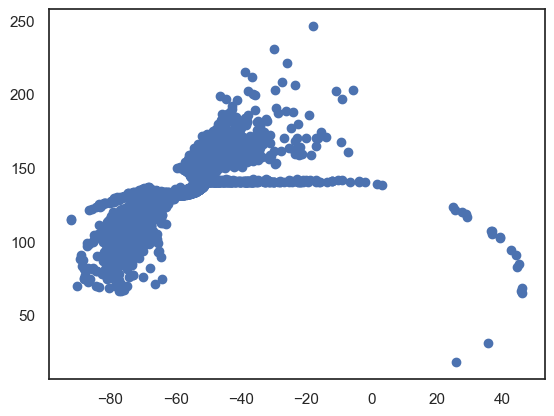

1.7509000000000001
target: R30


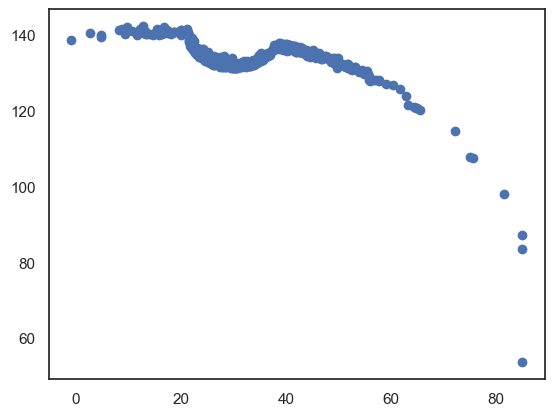

0.8508
target: R60


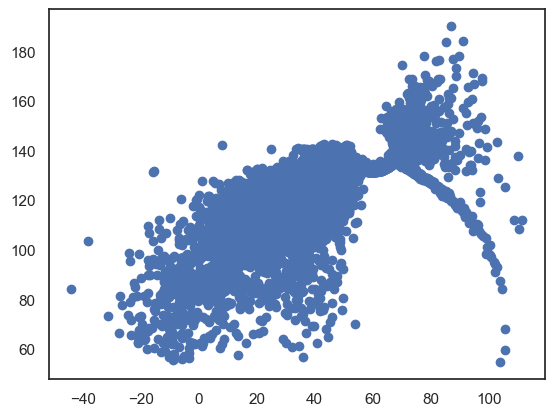

0.0031999999999999997


In [13]:

for t in np.unique(df_small_filt['target_x_label']):

    df_subset = df_small_filt[df_small_filt['target_x_label'] == t]

    
    print('target:', t)
    plt.scatter(df_subset['min_pos_from_target_x_cm'], df_subset['min_pos_from_target_z_cm'])
    plt.show()
    
    print(np.abs(df_subset['min_pos_from_target_x_cm']).min())

In [ ]:
### APPLY PCA

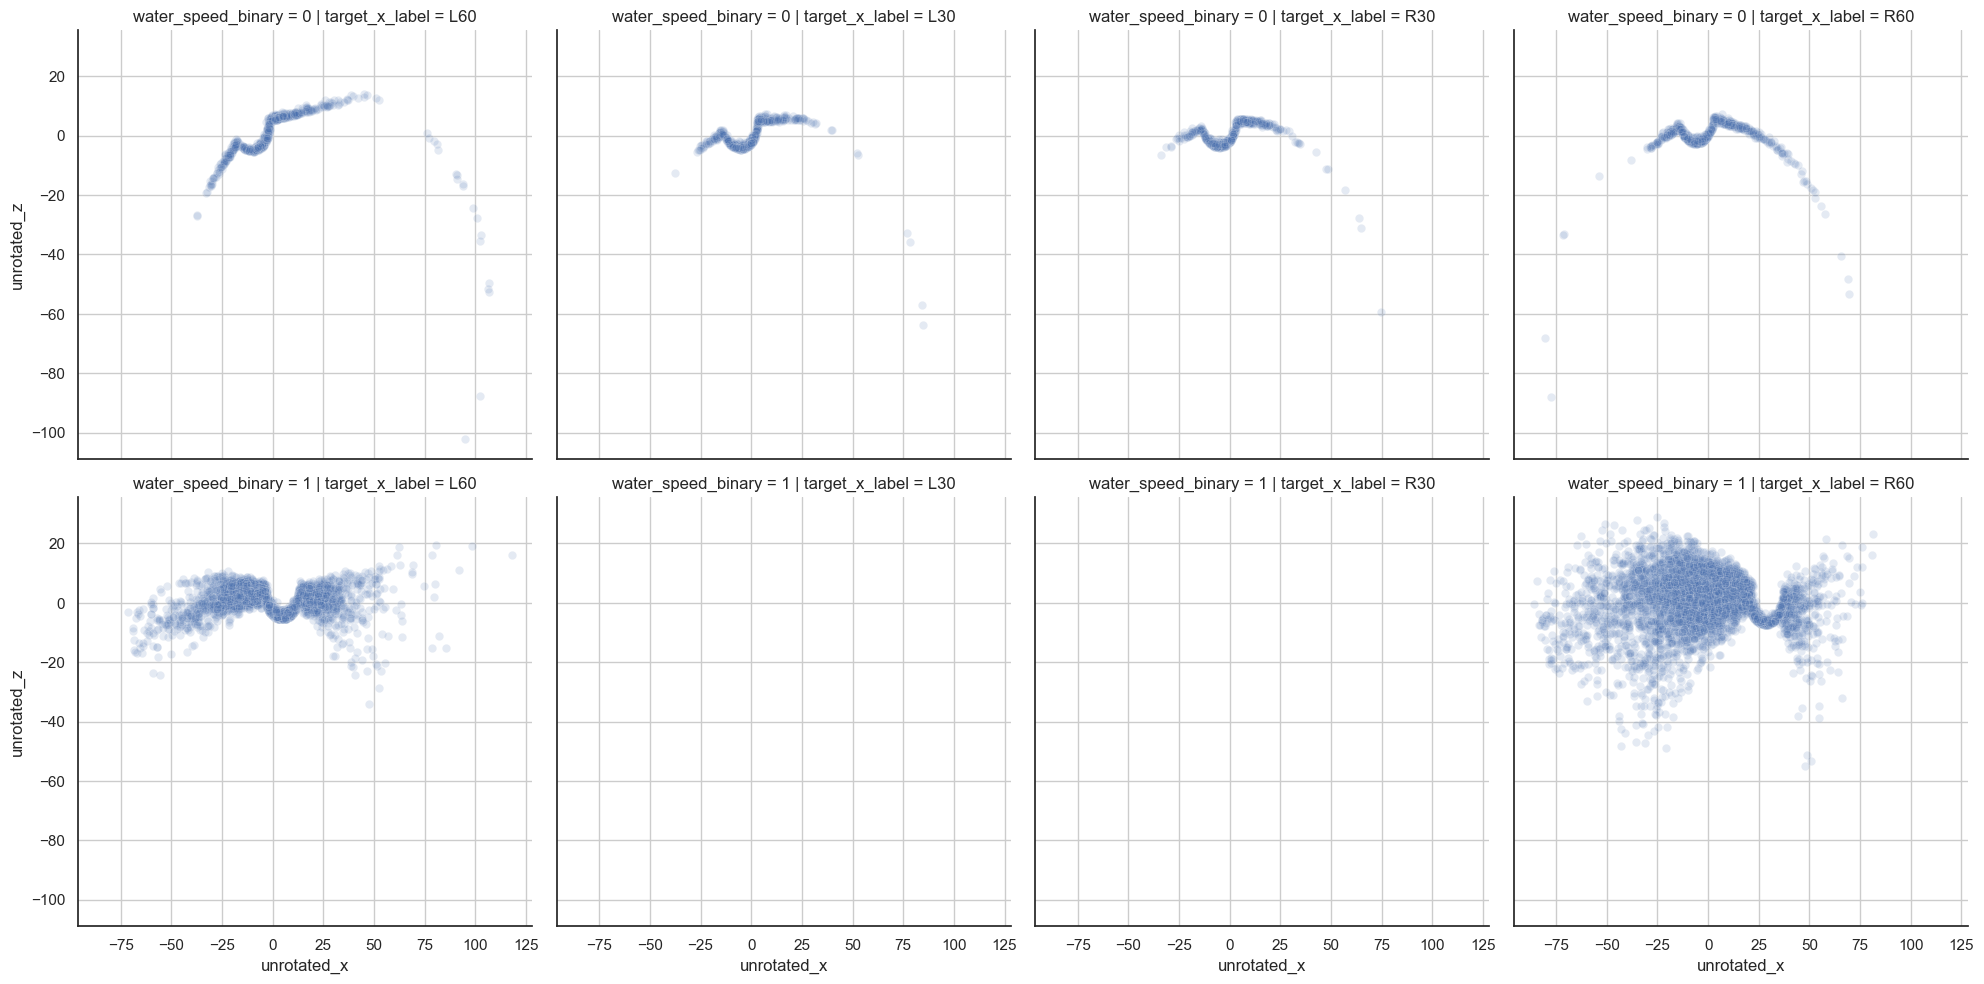

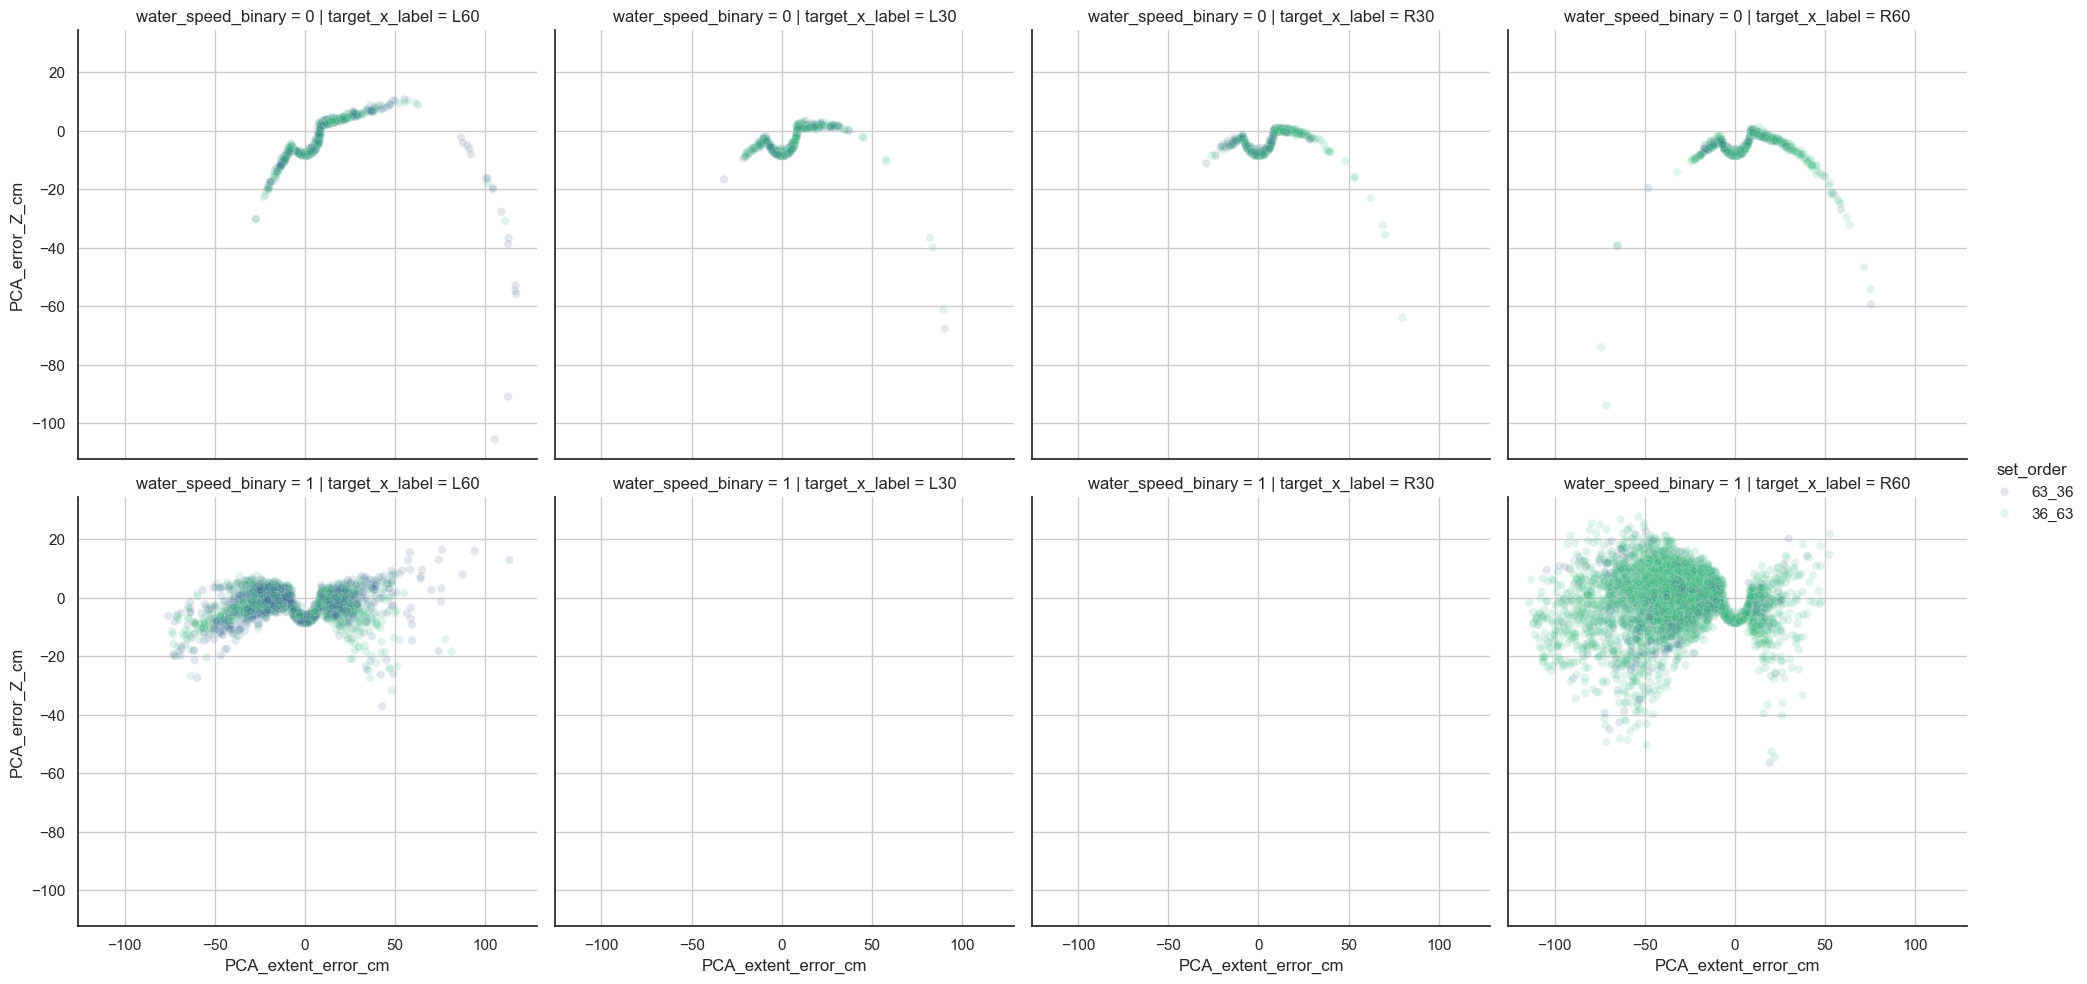

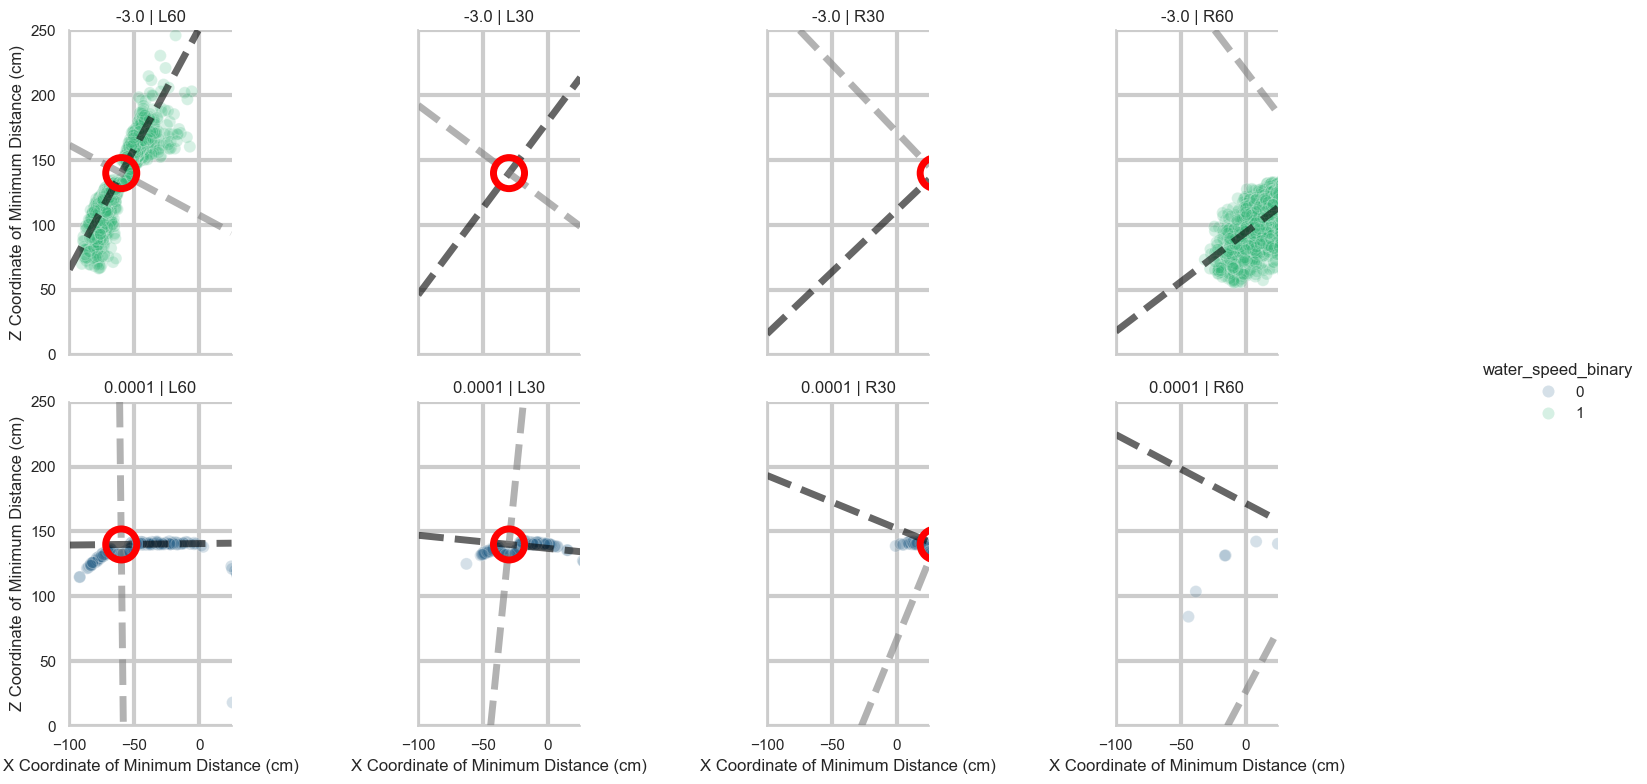

In [15]:
from src.PCA import compute_PCA_summary

features = ['min_pos_from_target_x_cm', 'min_pos_from_target_z_cm']
target_x_col = 'target_position_x_cm'
target_z_col = 'target_position_z_cm'


PCA_table = compute_PCA_summary(df_small_filt,
            features = features,
            group_cols = ['water_speed_m_s','target_position_x_cm'],
            water_col = 'water_speed_m_s',
            n_components=2
            )
PCA_table

# extract relevant columns
PCA_table_small = PCA_table.iloc[:, 0:9].copy()
PCA_table_small


# merge small summary table into raw df with trial-by-trial data
df_angles = df_small_filt.copy()
 
group_cols = ['water_speed_m_s','target_position_x_cm']
new_cols = ['pc_vector_1_angle','pc_vector_1_pca_center_x','pc_vector_1_pca_center_z','pc_vector_1_c_X','pc_vector_1_c_Z']

df_angles_v = df_angles.merge(PCA_table_small[group_cols + new_cols], how="left", on=group_cols)

from src.PCA import compute_PCA_error

PCA_error_df = compute_PCA_error(trial_df=df_angles_v,
                  pc_deg='pc_vector_1_angle',
                  target_x_col=target_x_col,
                  target_z_col=target_z_col,
                  features = features,
                  group_cols = ['water_speed_m_s','target_position_x_cm'],
                  water_col = 'water_speed_m_s',
                  show_plots = True
                 )


from src.plotting import plot_min_x_z

plot_min_x_z(PCA_error_df,
             c_col='target_x_label',
             r_col='water_speed_m_s',
             slope_array=[[61.685831, 53.243388, 43.616088, 37.305211],  # 3.0 m/s
                          [0.656367, -5.779064, -22.239128, -27.872954]], # 0.0 m/s
             target_x_array=[-60, -30, 30, 60], 
             show_slopes=True,
             show_orthogonal=True,
             show_target=True,
             x_col_title = 'X Coordinate of Minimum Distance (cm)',
             y_col_title = 'Z Coordinate of Minimum Distance (cm)',
             context='notebook'
            )

# Signed Minimum Metric Error

In [17]:

PCA_error_df['min_distance_target_x_cm'] = PCA_error_df['min_pos_from_target_x_cm']-PCA_error_df['target_position_x_cm']
PCA_error_df['min_distance_target_z_cm'] = PCA_error_df['min_pos_from_target_z_cm']-PCA_error_df['target_position_z_cm']

PCA_error_df['flip_min_distance_xPCA'] = np.sqrt(PCA_error_df['min_distance_target_x_cm']**2 + PCA_error_df['min_distance_target_z_cm']**2) * np.sign(PCA_error_df['PCA_extent_error_cm'])*-1


# Baseline & Cleaning

--- Baseline Trial Outlier Removal (flip_min_distance_xPCA) ---
Baseline Mean: -3.8658, SD: 14.3319
SD Threshold: 2.0 (28.6637 units)
Trials removed: 45 / 1151 total baseline trials
PCA_error_df (12972, 52)
clean_df (12927, 52)
hit min None
hit max None


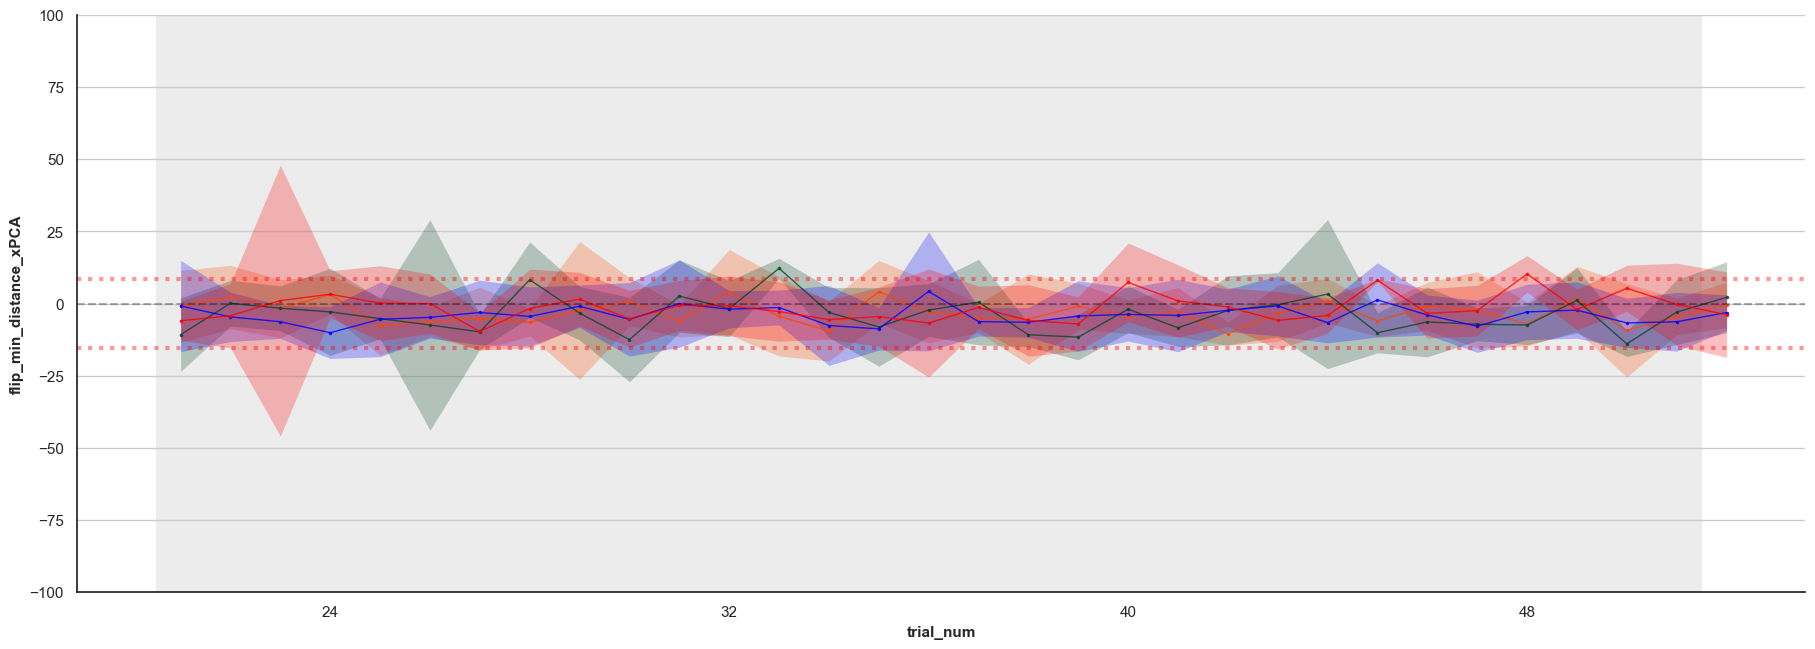

In [19]:
from src.cleaning import remove_baseline_outlier_trials_threshold_sd

# tag baseline outlier ppid
clean_df = remove_baseline_outlier_trials_threshold_sd(PCA_error_df,
                            y_col='flip_min_distance_xPCA',
                            trial_col='trial_num'
                               )

print('PCA_error_df', PCA_error_df.shape)
print('clean_df', clean_df.shape)

from src.plotting import plot_all_trials

df_baseline_clean = clean_df[clean_df['phase'] == 'baseline']

plot_all_trials(df_baseline_clean, 
                     col_col =None,
                     row_col=None,
                     cond_col='phase',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'flip_min_distance_xPCA', 
                     x_col='trial_num',
                     context='notebook', 
                     transition_col='water_speed_binary',
                     font_scale=3,
                     marker_size=1.5,
                     estimator='mean',
                     y_lim=(-100,100),
                     show_zero_line=True,
                     show_sd_line=True
                    )




Across ALL trials, remove outlier trials greater than 3.0 SD

         phase  trial_num  removed_count
0   training_1         95              1
1   training_1        102              1
2   training_1        142              1
3   training_1        156              1
4   training_1        174              1
5   training_1        203              1
6   training_1        235              1
7   training_1        250              1
8   training_1        252              1
9   training_1        260              1
10  training_1        269              1
11  training_1        271              1
12  training_1        273              1
13  training_2        346              1
14  training_2        354              1
15  washout_ST        278              1
16  washout_ST        279              1
17  washout_ST        281              1
18  washout_ST        288              2
--- Trial-by-Trial Outlier Removal (flip_min_distance_xPCA) ---
SD Threshold: 3.0
Trials removed: 20 / 12927 total rows


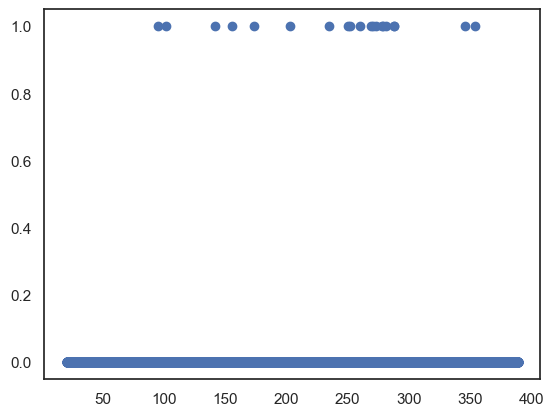

(12907, 53)


In [21]:
from src.cleaning import remove_outliers_per_trial

clean_df_ALL = remove_outliers_per_trial(clean_df,
                              y_col='flip_min_distance_xPCA',
                              trial_col='trial_num',
                              water_col='water_speed_m_s',
                              target_col='target_x_label',
                              phase_col='phase'
                             )

print(clean_df_ALL.shape)

# Baseline Correct and Export Preprocessed dfs

In [23]:
from src.baseline_correct import baseline_correct

df_bc = baseline_correct(data = clean_df_ALL,
                phase_col = 'phase',
                baseline_string='baseline',
                y_col='launch_deviation',
                PCA_col='flip_min_distance_xPCA' 
                        )
df_bc

# Extract and join unique experiment strings
unique_exps = df_bc['experiment'].unique().astype(str)
exp_tags = "_".join(unique_exps[:2]) 
if len(unique_exps) > 2:
    exp_tags += "_etc"
    
# Extract unique water speeds, rounded to prevent floating point noise
speeds = df_bc['water_speed_m_s'].unique()
speed_tags = "_".join([str(round(s, 1)).replace('-', 'neg').replace('.', '_') for s in np.sort(speeds)])

# construct the combined filename
file_name = f"PCA_error_{exp_tags}_speed_{speed_tags}.csv"
file_path = f"..\\data\\spatial_generalization\\{file_name}"

df_bc.to_csv(file_path, index=False)
print(f"Saved: {file_path}")
print(df_bc.columns)





from src.early_late_exposure import early_late_phase_new

df_tmp = df_bc.copy()

early_late_phase_df_2 = early_late_phase_new(df_tmp,
                                       group_cols=['ppid_full'],
                                       phase_col='phase',
                                       phases_to_keep=['training_1','training_2'],
                                       trial_col='phase_target_trial_num', 
                                       n_trials=2
                                      ).copy()

# Extract and join unique experiment strings
exp_tags = "_".join(early_late_phase_df_2['experiment'].unique().astype(str))

# Extract unique water speeds, rounded to prevent floating point noise
speeds = early_late_phase_df_2['water_speed_m_s'].unique()
speed_tags = "_".join([str(round(s, 1)).replace('-', 'neg').replace('.', '_') for s in np.sort(speeds)])

# construct the combined filename
file_name = f"early_late_phase_2_PCA_error_{exp_tags}_speed_{speed_tags}.csv"
file_path = f"..\\data\\spatial_generalization\\{file_name}"

early_late_phase_df_2.to_csv(file_path, index=False)
print(f"Saved: {file_path}")

C:\Users\jacob\water_current_MA\src\baseline_correct.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_merged.groupby(['target_x_label'])[f"{y_col}_mean"].mean())


target_x_label
L60   -0.659992
L30   -0.524038
R30   -1.427138
R60   -0.662293
Name: launch_deviation_mean, dtype: float64
Saved: ..\data\spatial_generalization\PCA_error_novel_TU_3.0M_spatial_generalization_novel_TD_3.0M_spatial_generalization_speed_neg3_0_0_0.csv
Index(['experiment', 'ppid_full', 'speed_label', 'target_x_label',
       'target_position_x_cm', 'target_position_z_cm', 'trial_num', 'phase',
       'phase_trial_num', 'phase_target_trial_num', 'trial_num_target',
       'global_cycle_num', 'cycle_target_num', 'cycle_TargetxPhase_num',
       'launch_angle', 'launch_deviation', 'launch_Speed',
       'distance_from_target', 'ball_dist_to_center_cm', 'signed_euclidean_cm',
       'lateral_error_x_cm', 'depth_error_z_cm', 'target_hit',
       'water_speed_binary', 'water_speed_m_s', 'sign_label', 'set_order',
       'min_pos_from_target_x_cm', 'min_pos_from_target_z_cm',
       'target_angle_90', 'ball_pos_x', 'ball_pos_z', 'final_ball_pos_x',
       'pc_vector_1_angle', 'pc

C:\Users\jacob\water_current_MA\src\early_late_exposure.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby(group_cols + [phase_col])


# Baseline

52
hit min None
hit max None


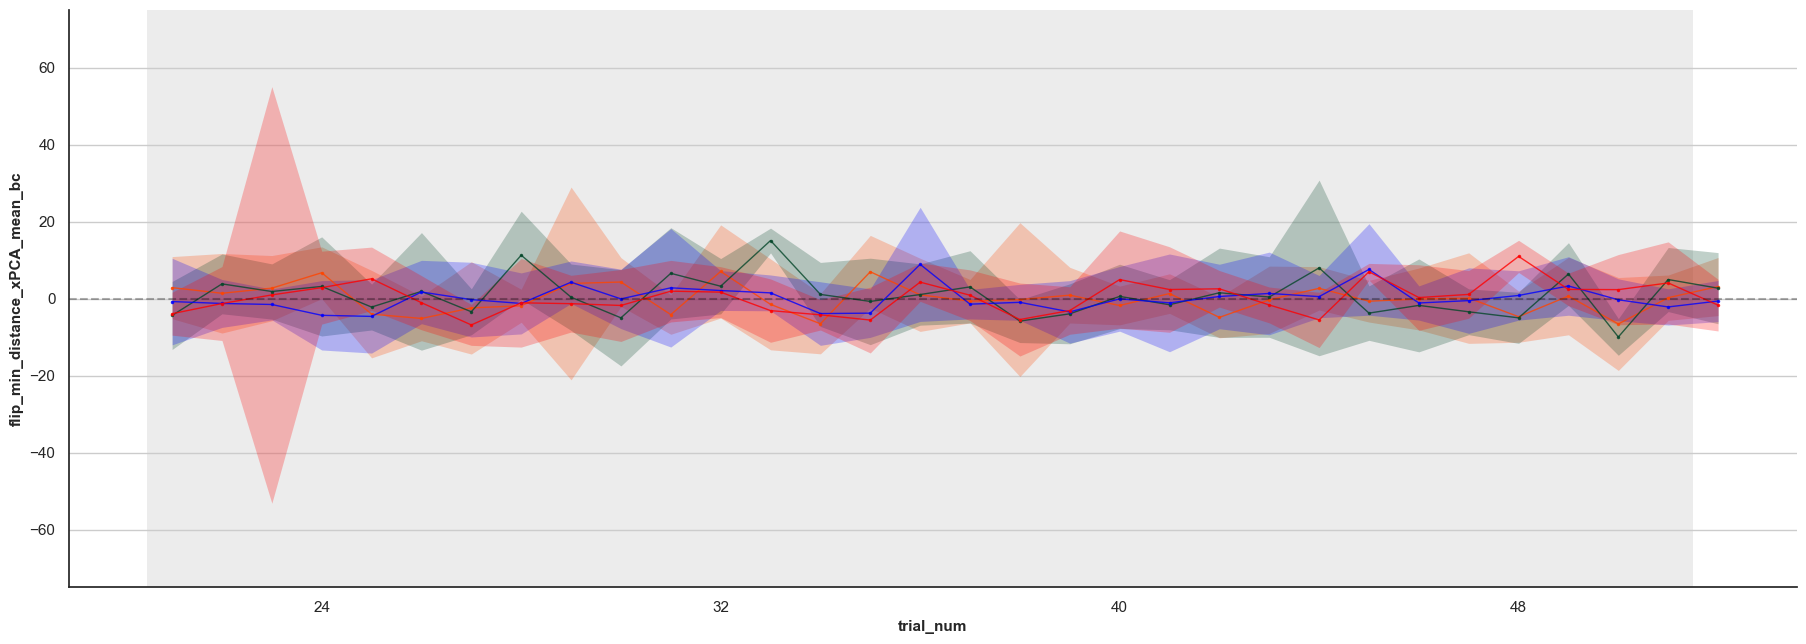

In [31]:
from src.plotting import plot_all_trials

df_bc_baseline = df_bc[df_bc['phase'] == 'baseline']
print(df_bc_baseline['trial_num'].max())

plot_all_trials(df_bc_baseline, 
                     col_col =None,
                     row_col=None,
                     cond_col='phase',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'flip_min_distance_xPCA_mean_bc', 
                     x_col='trial_num',
                     context='notebook', 
                     transition_col='water_speed_binary',
                     font_scale=3,
                     marker_size=1.5,
                     estimator='mean',
                     y_lim=(-75,75),
                     show_zero_line=True,
                     show_sd_line=False
                    )




hit min None
hit max None


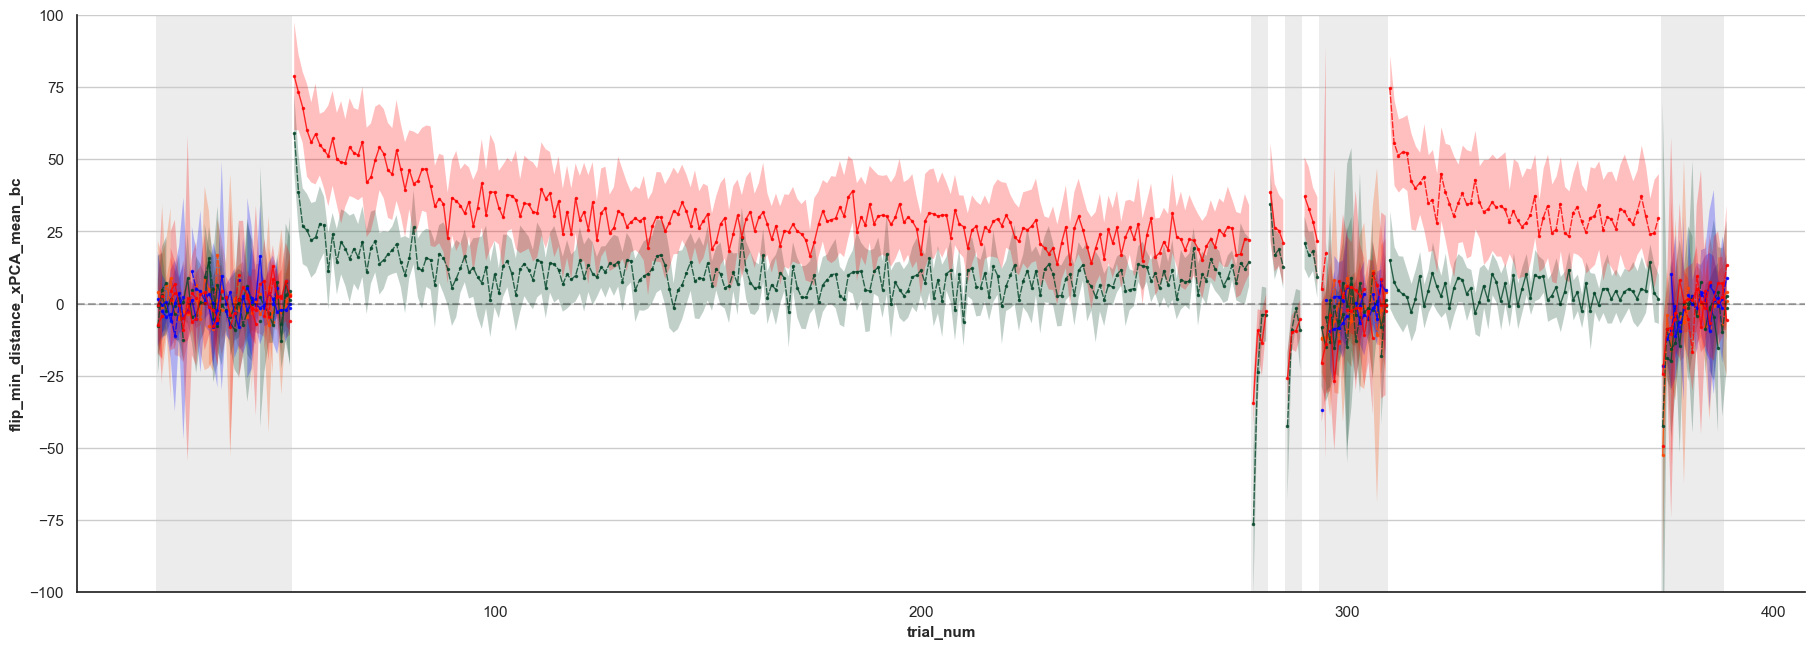

In [33]:
from src.plotting import plot_all_trials

plot_all_trials(df_bc, 
                     col_col =None,
                     row_col=None,
                     cond_col='experiment',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'flip_min_distance_xPCA_mean_bc', 
                     x_col='trial_num',
                     context='poster', 
                     transition_col='water_speed_binary',
                     font_scale=3,
                     marker_size=1.5,
                     estimator='mean',
                     y_lim=(-100,100),
                     show_zero_line=True
                    )




hit min None
hit max None


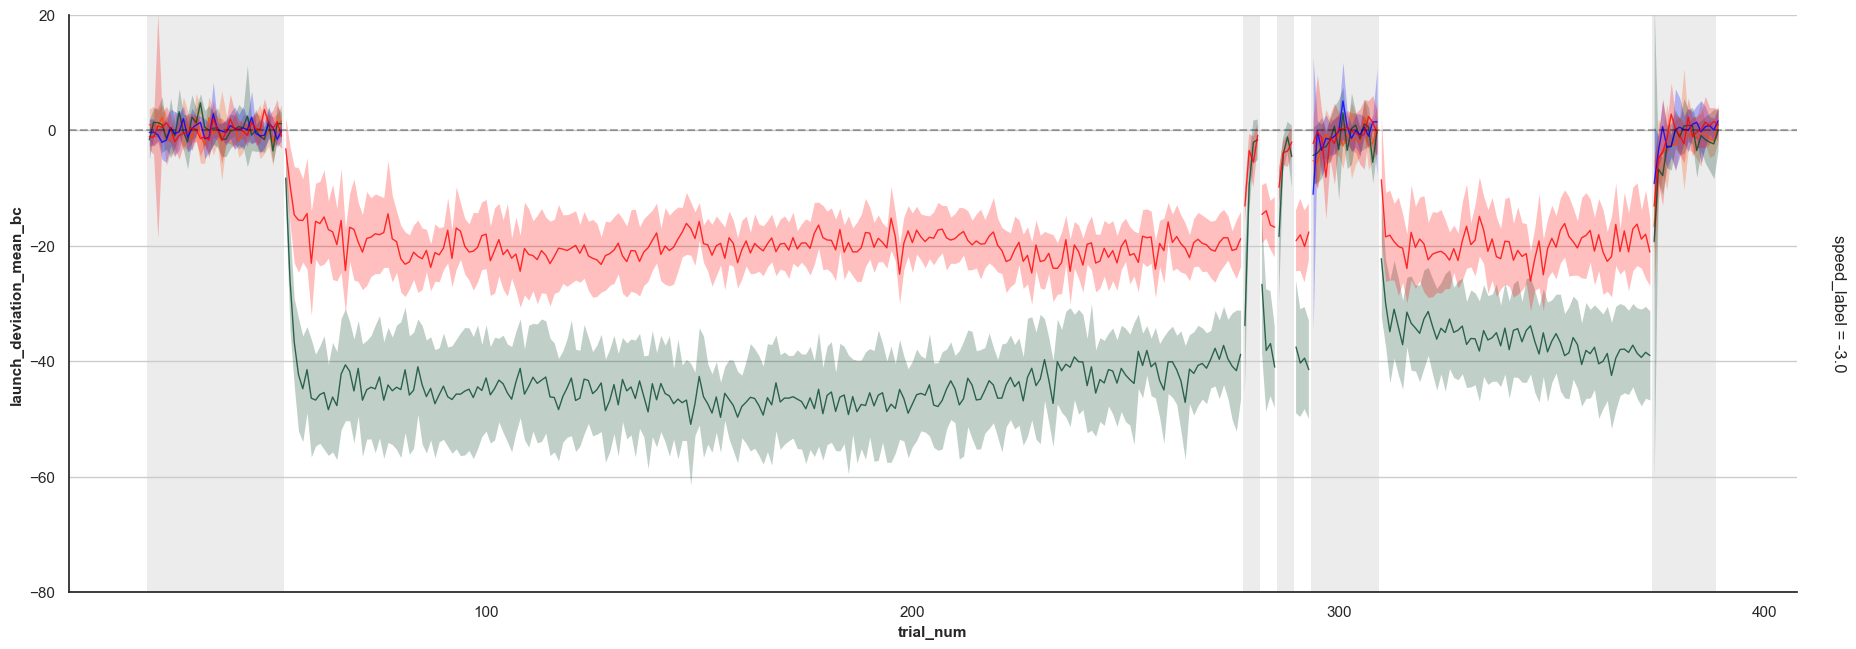

In [73]:
from src.plotting import plot_all_trials

plot_all_trials(df_bc, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col=None,
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'launch_deviation_mean_bc', # 
                     x_col='trial_num',
                     vertical_list= None,
                     hit_col='target_hit',
                     ref_range_col=None,
                     no_connect_col='phase',
                     context='notebook', 
                     transition_col='water_speed_binary',
                     marker_size=0.0,
                     estimator='mean',
                     y_lim=(-80,20),
                     show_zero_line=True
                    )                    

hit min None
hit max None


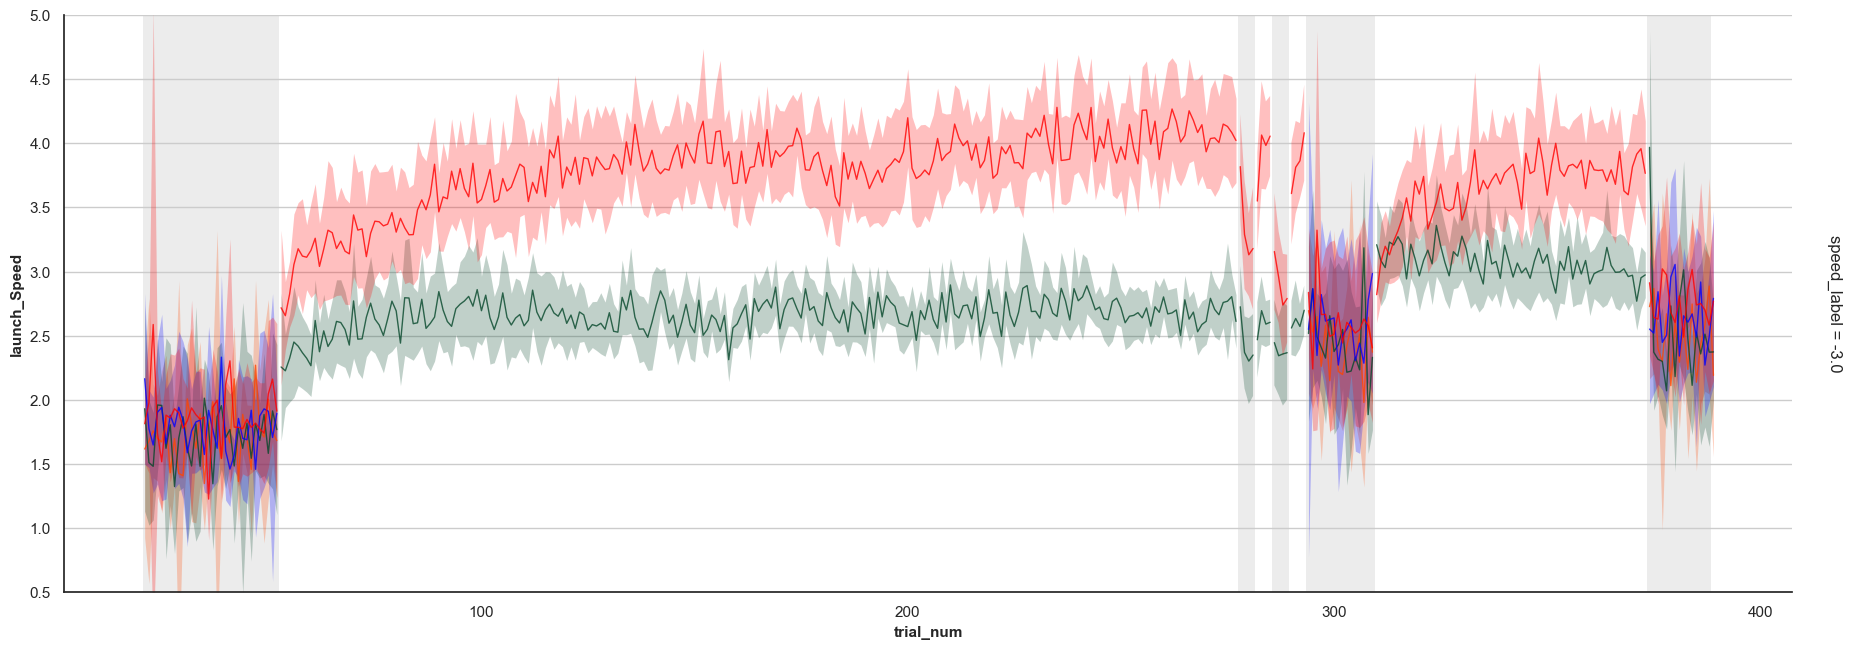

In [75]:
from src.plotting import plot_all_trials

plot_all_trials(df_bc, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col=None,
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'launch_Speed', # 
                     x_col='trial_num',
                     vertical_list= None,
                     hit_col='target_hit',
                     ref_range_col=None,
                     no_connect_col='phase',
                     context='notebook', 
                     transition_col='water_speed_binary',
                     marker_size=0.0,
                     estimator='mean',
                     y_lim=(0.5,5.0),
                     show_zero_line=True
                    )                    

First and Last 2 trials - Training Phase 1

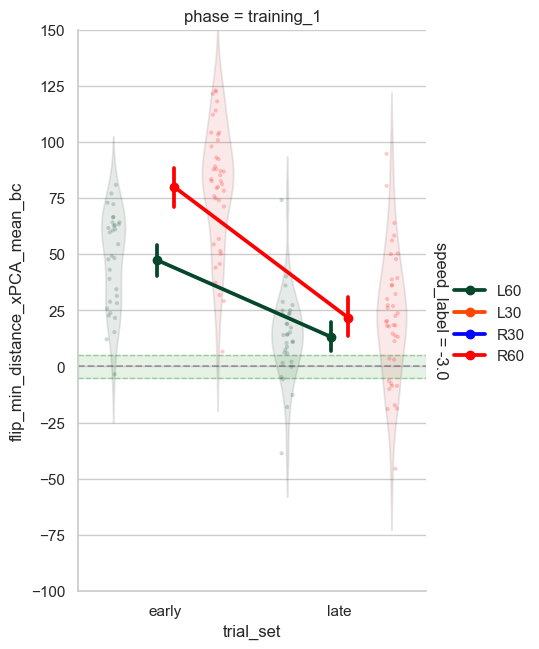

In [35]:
from src.plotting import plot_slopes

early_late_phase_df_2_t1 = early_late_phase_df_2[early_late_phase_df_2['phase'] == "training_1"]

plot_slopes(early_late_phase_df_2_t1,
                         x_col='trial_set',
                         y_col='flip_min_distance_xPCA_mean_bc',
                         hue_var='target_x_label', 
                         facet_col='phase',
                         facet_row= 'speed_label'
                            )



First and Last 2 trials - Training Phase 2

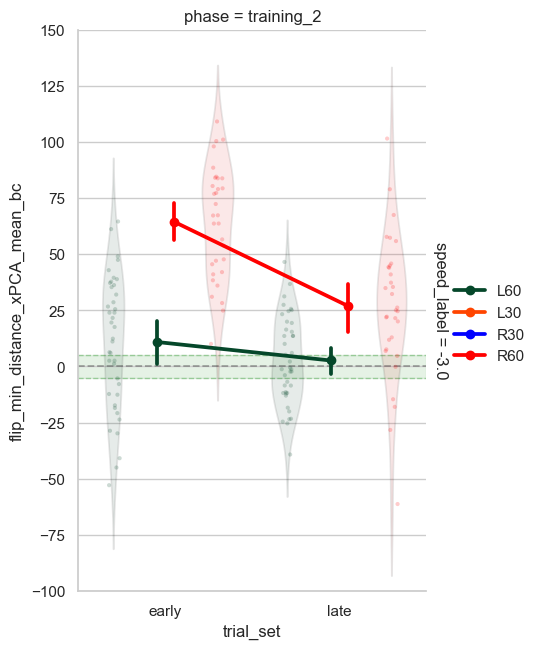

In [39]:
from src.plotting import plot_slopes

early_late_phase_df_2_t2 = early_late_phase_df_2[early_late_phase_df_2['phase'] == "training_2"]

plot_slopes(early_late_phase_df_2_t2,
                         x_col='trial_set',
                         y_col='flip_min_distance_xPCA_mean_bc',
                         hue_var='target_x_label', 
                         facet_col='phase',
                         facet_row= 'speed_label'
                            )



# Between-Subjects Transfer

First 2 trials of T1 (Naive) vs First 2 trials of T2 (Experienced) on the SAME target

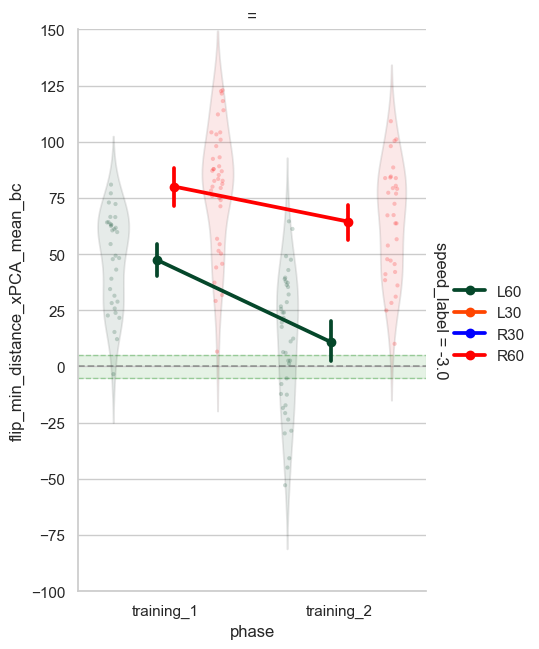

In [44]:

early_df_2 = early_late_phase_df_2[early_late_phase_df_2['trial_set'] == 'early'].copy()
early_df_2['phase'] = early_df_2['phase'].astype(str) # for plotting

from src.plotting import plot_slopes
plot_slopes(early_df_2,
                         x_col='phase',
                         y_col='flip_min_distance_xPCA_mean_bc',
                         hue_var='target_x_label', 
                         facet_col=None,
                         facet_row='speed_label'            
                            )



In [23]:
# filter and save baseline-washout data csv

from src.baseline_washout import retain_baseline_washout



t = retain_baseline_washout(df_bc,
                           phase_col='phase',
                           experiment_type ='spatial_generalization',
                           phases_to_keep = ['baseline','washout_ST','washout_1_AT','washout_2_AT'],
                           experiment_col = 'experiment',
                           water_col = 'water_speed_binary')
t


Saved: ..\data\spatial_generalization\baseline_washout_novel_TU_3.0M_spatial_generalization_novel_TD_3.0M_spatial_generalization_speed_0.csv


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


In [25]:
np.unique(t['water_speed_m_s'])

array([0.0001])

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

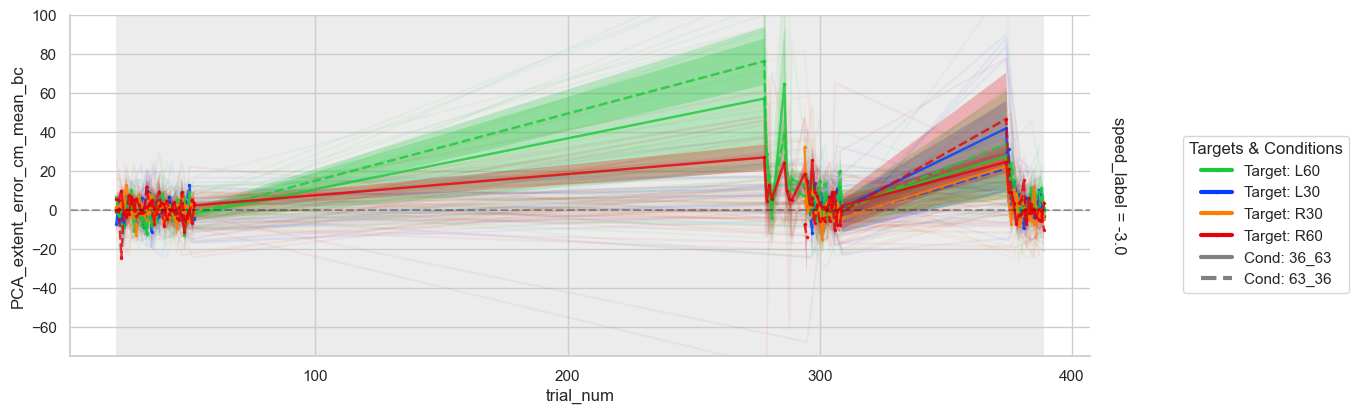

In [27]:


# plot across washout
from src.plotting import plot_all_trials
plot_all_trials(t, 
                     col_col = None,
                     row_col='speed_label',
                     cond_col='set_order',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'PCA_extent_error_cm_mean_bc', 
                     x_col='trial_num',
                     context='poster', 
                     transition_col='water_speed_binary',
                     font_scale=3,
                     marker_size=1.5,
                     estimator='mean',
                     y_lim=(-75,100),
                     show_zero_line=True
                    )